# EEGMAT Preprocessing
Notebook covers EDA and preprocessing of data. Feature extracted data is outputted and stored in \data



Dataset Link: https://physionet.org/content/eegmat/1.0.0/

In [35]:
import os
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch

# Project root = parent of EDA if we're in EDA, else cwd
_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "EDA" else _cwd
DATA_ROOT = os.path.join(_root, "data", "eegmat")
OUTPUT_FEATURES_CSV = os.path.join(DATA_ROOT, "eegmat_bandpower_segments.csv")

print("Data root:", os.path.abspath(DATA_ROOT))
print("Exists:", os.path.isdir(DATA_ROOT))

# list EDF files
all_files = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith('.edf'):
            all_files.append(os.path.join(root, f))

Data root: c:\Users\Ryan_pc\COGS189\workload\data\eegmat
Exists: True


In [36]:
# Inspect file naming convention to understand baseline vs task ordering
from pprint import pprint

# Manually open 1–2 files in MNE info to double-check metadata
raw_example = mne.io.read_raw_edf(all_files[0], preload=False)
raw_example.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F3, EEG F4, EEG F7, EEG F8, EEG T3, EEG ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 45.0 Hz
 meas_date: 2011-01-01 00:00:00 UTC
 nchan: 21
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: 0, sex: 1, last_name: Subject0, birthday: 1990-01-01>
>

In [37]:
# Dataset is already: 30 Hz low-pass, 50 Hz notch, ICA artifact removal. No ICA here needed since it was already done.
sfreq_target = 256  # resample if needed
l_freq, h_freq = 1., 30.  # bandpass
window_sec = 2.0  # non-overlapping segments, preserves temporality

BANDS = {"theta": (4, 8), "alpha": (8, 12), "beta": (13, 30)}
print("Bands:", BANDS)

Bands: {'theta': (4, 8), 'alpha': (8, 12), 'beta': (13, 30)}


In [38]:
def compute_bandpower_welch(data, sfreq, bands):
    #Compute bandpower per channel for each band using Welch.

    freqs, psd = welch(data, sfreq, nperseg=int(2 * sfreq))  # 2 s windows
    band_powers = {}
    for name, (fmin, fmax) in bands.items():
        idx = np.logical_and(freqs >= fmin, freqs <= fmax)
        band_powers[name] = np.trapz(psd[:, idx], freqs[idx], axis=1)
    return band_powers

In [39]:
def segment_raw_to_bandpower_df(raw, label, subject_id, recording_id):
    raw = raw.copy().filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)

    if raw.info['sfreq'] != sfreq_target:
        raw.resample(sfreq_target)

    data = raw.get_data()  # (n_channels, n_times)
    sfreq = raw.info['sfreq']
    n_channels, n_times = data.shape

    window_samples = int(window_sec * sfreq)
    n_windows = n_times // window_samples

    rows = []
    ch_names = raw.info['ch_names']

    for w in range(n_windows):
        start = w * window_samples
        stop = start + window_samples
        seg = data[:, start:stop]
        band_powers = compute_bandpower_welch(seg, sfreq, BANDS)

        row = {
            'subject_id': subject_id,
            'recording_id': recording_id,
            'segment_idx': w,
            'label': label,  # 0 = baseline, 1 = task (we'll enforce this mapping)
        }

        for band_name, vals in band_powers.items():
            for ch, ch_name in enumerate(ch_names):
                row[f'{band_name}_{ch_name}'] = vals[ch]

        rows.append(row)

    return pd.DataFrame(rows)

In [40]:
def parse_subject_and_condition(path):
    fname = os.path.basename(path)
    # EEGMAT: _1 = background/baseline, _2 = during mental arithmetic task
    if '_1.' in fname or fname.endswith('_1.edf'):
        label = 0  # baseline (low workload)
        condition = 'baseline'
    elif '_2.' in fname or fname.endswith('_2.edf'):
        label = 1  # task (high workload)
        condition = 'task'
    else:
        raise ValueError(f"Unknown condition for file: {path}")
    # Subject id: e.g. Subject00 -> 00, Subject12 -> 12
    base = fname.split('.')[0]
    subj = base.replace('Subject', '').split('_')[0]
    return subj, condition, label

In [41]:
def get_segments_from_raw(raw):
    """Return list of (n_channels, n_times) arrays for CSP. Use raw.pick('eeg') before calling."""
    raw = raw.copy().filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)
    if raw.info['sfreq'] != sfreq_target:
        raw.resample(sfreq_target)
    data = raw.get_data()
    n_channels, n_times = data.shape
    window_samples = int(window_sec * sfreq_target)
    n_windows = n_times // window_samples
    return [data[:, w * window_samples:(w + 1) * window_samples].copy() for w in range(n_windows)]

In [42]:
all_segments = []
all_segment_arrays = []  # (subject_id, label, segment_idx, data) for CSP

for i, edf_path in enumerate(sorted(all_files)):
    subj, condition, label = parse_subject_and_condition(edf_path)
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose='ERROR')

    df_segments = segment_raw_to_bandpower_df(
        raw=raw, label=label, subject_id=subj, recording_id=condition,
    )
    all_segments.append(df_segments)

    raw_eeg = raw.copy().pick('eeg')
    segs = get_segments_from_raw(raw_eeg)
    for seg_idx, arr in enumerate(segs):
        all_segment_arrays.append((subj, label, seg_idx, arr))

features_df = pd.concat(all_segments, ignore_index=True)
print(features_df.shape)
print("Segment arrays for CSP:", len(all_segment_arrays))
features_df.head()

(4338, 67)
Segment arrays for CSP: 4338


,subject_id,recording_id,segment_idx,label,theta_EEG Fp1,theta_EEG Fp2,theta_EEG F3,theta_EEG F4,theta_EEG F7,theta_EEG F8,...,beta_EEG T6,beta_EEG P3,beta_EEG P4,beta_EEG O1,beta_EEG O2,beta_EEG Fz,beta_EEG Cz,beta_EEG Pz,beta_EEG A2-A1,beta_ECG ECG
0,00,baseline,0,0,8.230781e-12,1.089378e-11,1.108751e-11,8.070233e-12,1.356126e-11,1.727897e-11,...,1.172093e-11,1.176494e-11,1.430940e-11,2.442675e-11,4.053214e-11,5.960407e-12,8.637142e-12,1.412838e-11,1.141470e-12,2.137296e-09
1,00,baseline,1,0,9.268282e-12,8.892937e-12,1.769324e-11,1.535522e-11,1.610250e-11,8.165809e-12,...,1.003203e-11,5.769486e-12,9.731033e-12,7.175125e-12,1.002375e-11,1.269855e-11,1.287391e-11,7.009352e-12,1.220406e-12,2.382531e-09
2,00,baseline,2,0,6.321962e-12,1.139815e-11,6.747887e-12,9.530494e-12,8.112675e-12,1.005060e-11,...,2.248864e-11,1.241378e-11,1.537948e-11,2.059991e-11,2.421764e-11,2.212177e-11,2.274492e-11,1.436223e-11,1.111232e-12,2.567919e-09
3,00,baseline,3,0,8.996813e-12,1.465802e-11,1.217375e-11,1.698796e-11,1.558309e-11,1.216414e-11,...,1.974454e-11,4.490952e-11,2.668262e-11,3.987606e-11,2.561226e-11,1.934992e-11,2.807244e-11,4.411119e-11,2.123295e-12,2.350360e-09
4,00,baseline,4,0,7.759277e-12,1.132600e-11,1.631360e-11,1.181184e-11,1.842302e-11,7.851705e-12,...,2.628189e-11,2.719266e-11,2.262312e-11,3.548510e-11,3.288838e-11,1.603332e-11,1.877462e-11,1.961471e-11,2.833497e-12,2.758257e-09


In [43]:
# CSP: normalize per channel (fit on train) -> fit CSP on train -> add CSP features
mne.set_log_level('WARNING')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from mne.decoding import CSP

# Subject-level split (no leakage)
subjects = features_df["subject_id"].unique()
train_subj, test_subj = train_test_split(subjects, test_size=0.2, random_state=42)
train_mask = np.array([s in train_subj for s in [x[0] for x in all_segment_arrays]])

# Stack segments: (n_epochs, n_channels, n_times)
X_all = np.stack([x[3] for x in all_segment_arrays])
y_all = np.array([x[1] for x in all_segment_arrays])
n_epochs, n_ch, n_times = X_all.shape

# Per-channel normalization: fit on train, apply to all
X_flat = X_all[train_mask].transpose(0, 2, 1).reshape(-1, n_ch)  # (n_train * n_times, n_ch)
scaler = StandardScaler().fit(X_flat)
X_norm = np.zeros_like(X_all)
for i in range(n_epochs):
    X_norm[i] = scaler.transform(X_all[i].T).T

# Fit CSP on normalized train (alpha band is typical for workload)
n_components = 4
csp = CSP(n_components=n_components, reg=None, log=True, norm_trace=False)
csp.fit(X_norm[train_mask], y_all[train_mask])

# Transform all -> log-variance already applied by CSP(log=True)
X_csp = csp.transform(X_norm)  # (n_epochs, n_components)

for j in range(n_components):
    features_df[f"csp_{j+1}"] = X_csp[:, j]
print("Added CSP features:", [f"csp_{j+1}" for j in range(n_components)])

Added CSP features: ['csp_1', 'csp_2', 'csp_3', 'csp_4']


In [44]:
# we care about EEG features, not ECG features for this project
ecg_cols = [c for c in features_df.columns if 'ECG' in c]
if ecg_cols:
    features_df = features_df.drop(columns=ecg_cols)
    print("Dropped ECG columns:", ecg_cols)
# Save features for downstream modeling
os.makedirs(os.path.dirname(OUTPUT_FEATURES_CSV), exist_ok=True)
features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)
print("Saved features to:", OUTPUT_FEATURES_CSV)

Dropped ECG columns: ['theta_ECG ECG', 'alpha_ECG ECG', 'beta_ECG ECG']
Saved features to: c:\Users\Ryan_pc\COGS189\workload\data\eegmat\eegmat_bandpower_segments.csv


## EDA (bandpower features; data already ICA- and filter-preprocessed)

In [45]:

import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = features_df.copy()
except NameError:
    df = pd.read_csv(OUTPUT_FEATURES_CSV)

df["label_name"] = df["label"].map({0: "baseline", 1: "task"})
meta = ["subject_id", "recording_id", "segment_idx", "label", "label_name"]
feature_cols = [c for c in df.columns if c not in meta]
sns.set_style("whitegrid")
print("Segments:", len(df), "| Features:", len(feature_cols))

Segments: 4338 | Features: 64


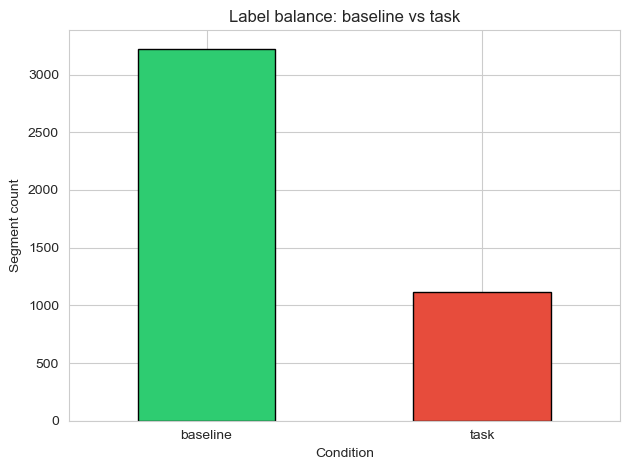

In [46]:
# Segment counts by condition (baseline vs task)
ax = df["label_name"].value_counts().sort_index().plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="black")
ax.set_ylabel("Segment count")
ax.set_xlabel("Condition")
ax.set_title("Label balance: baseline vs task")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

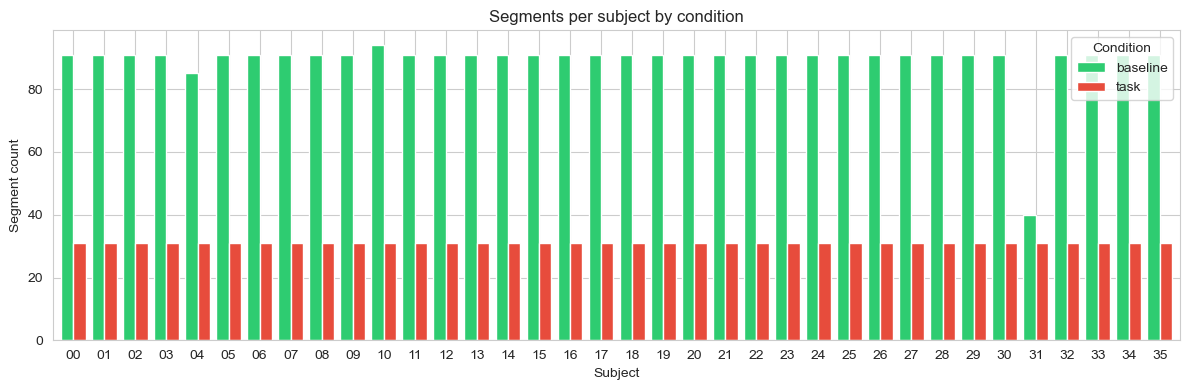

In [47]:
# Segments per subject (and per condition)
counts = df.groupby(["subject_id", "label_name"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=False, figsize=(12, 4), width=0.8, color=["#2ecc71", "#e74c3c"])
plt.ylabel("Segment count")
plt.xlabel("Subject")
plt.title("Segments per subject by condition")
plt.legend(title="Condition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

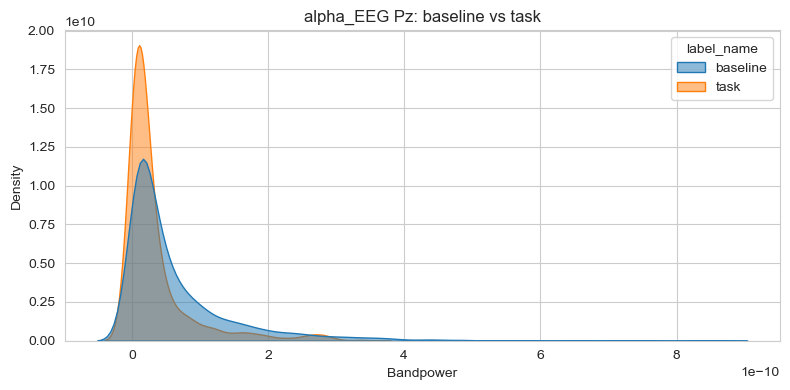

In [48]:
# Feature distribution by condition: alpha at Pz (typical workload-sensitive channel)
col = "alpha_EEG Pz"
if col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, hue="label_name", common_norm=False, fill=True, alpha=0.5, ax=ax)
    ax.set_title(f"{col}: baseline vs task")
    ax.set_xlabel("Bandpower")
    plt.tight_layout()
    plt.show()
else:
    print("Pick a feature from feature_cols, e.g.", [c for c in feature_cols if "alpha" in c and "Pz" in c][:1])

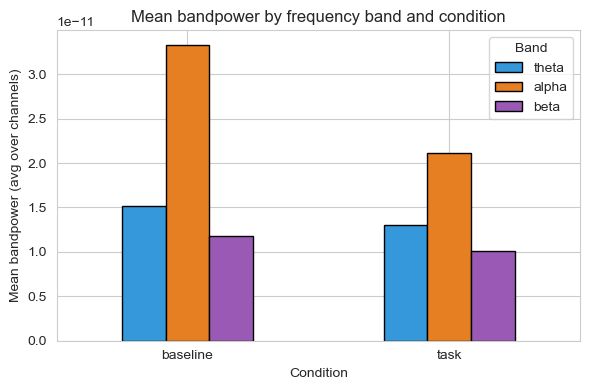

In [49]:
# Mean bandpower by band and condition (averaged over channels)
band_means = {}
for band in ["theta", "alpha", "beta"]:
    cols = [c for c in feature_cols if c.startswith(band + "_")]
    if cols:
        band_means[band] = df.groupby("label_name")[cols].mean().mean(axis=1)
pd.DataFrame(band_means).plot(kind="bar", figsize=(6, 4), color=["#3498db", "#e67e22", "#9b59b6"], edgecolor="black")
plt.ylabel("Mean bandpower (avg over channels)")
plt.xlabel("Condition")
plt.title("Mean bandpower by frequency band and condition")
plt.xticks(rotation=0)
plt.legend(title="Band")
plt.tight_layout()
plt.show()

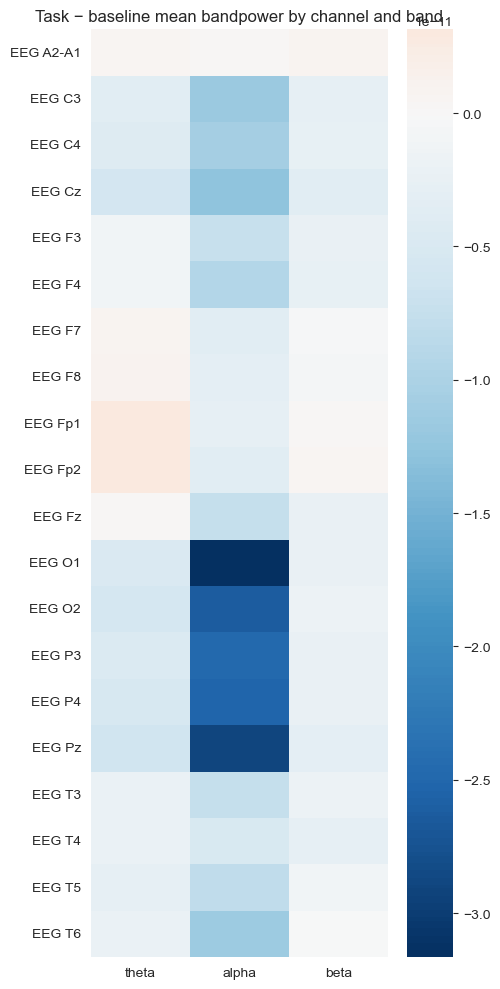

In [ ]:
# Heatmap: mean bandpower by channel and band (difference task − baseline)
baseline_means = df[df["label"] == 0][feature_cols].mean()
task_means = df[df["label"] == 1][feature_cols].mean()
diff = (task_means - baseline_means).to_dict()
bandpower_cols = [c for c in feature_cols if c.startswith(("theta_", "alpha_", "beta_"))]
channels = sorted(set(c.split("_", 1)[1] for c in bandpower_cols))
bands = ["theta", "alpha", "beta"]
matrix = np.array([[diff.get(f"{b}_{ch}", np.nan) for b in bands] for ch in channels])
fig, ax = plt.subplots(figsize=(5, 10))
sns.heatmap(matrix, xticklabels=bands, yticklabels=channels, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Task − baseline mean bandpower by channel and band")
plt.tight_layout()
plt.show()

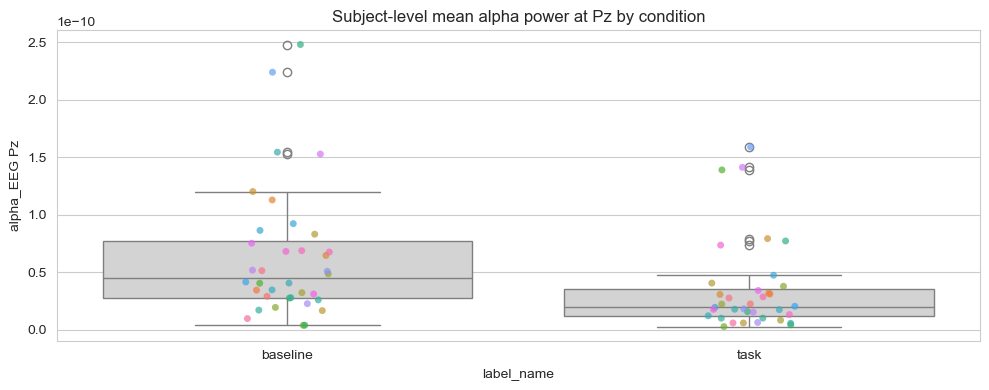

In [51]:
# Subject-level: mean alpha Pz by condition 
col = "alpha_EEG Pz"
if col in df.columns:
    subj_means = df.groupby(["subject_id", "label_name"])[col].mean().reset_index()
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=subj_means, x="label_name", y=col, color="lightgray")
    sns.stripplot(data=subj_means, x="label_name", y=col, hue="subject_id", legend=False, alpha=0.7)
    plt.title("Subject-level mean alpha power at Pz by condition")
    plt.tight_layout()
    plt.show()

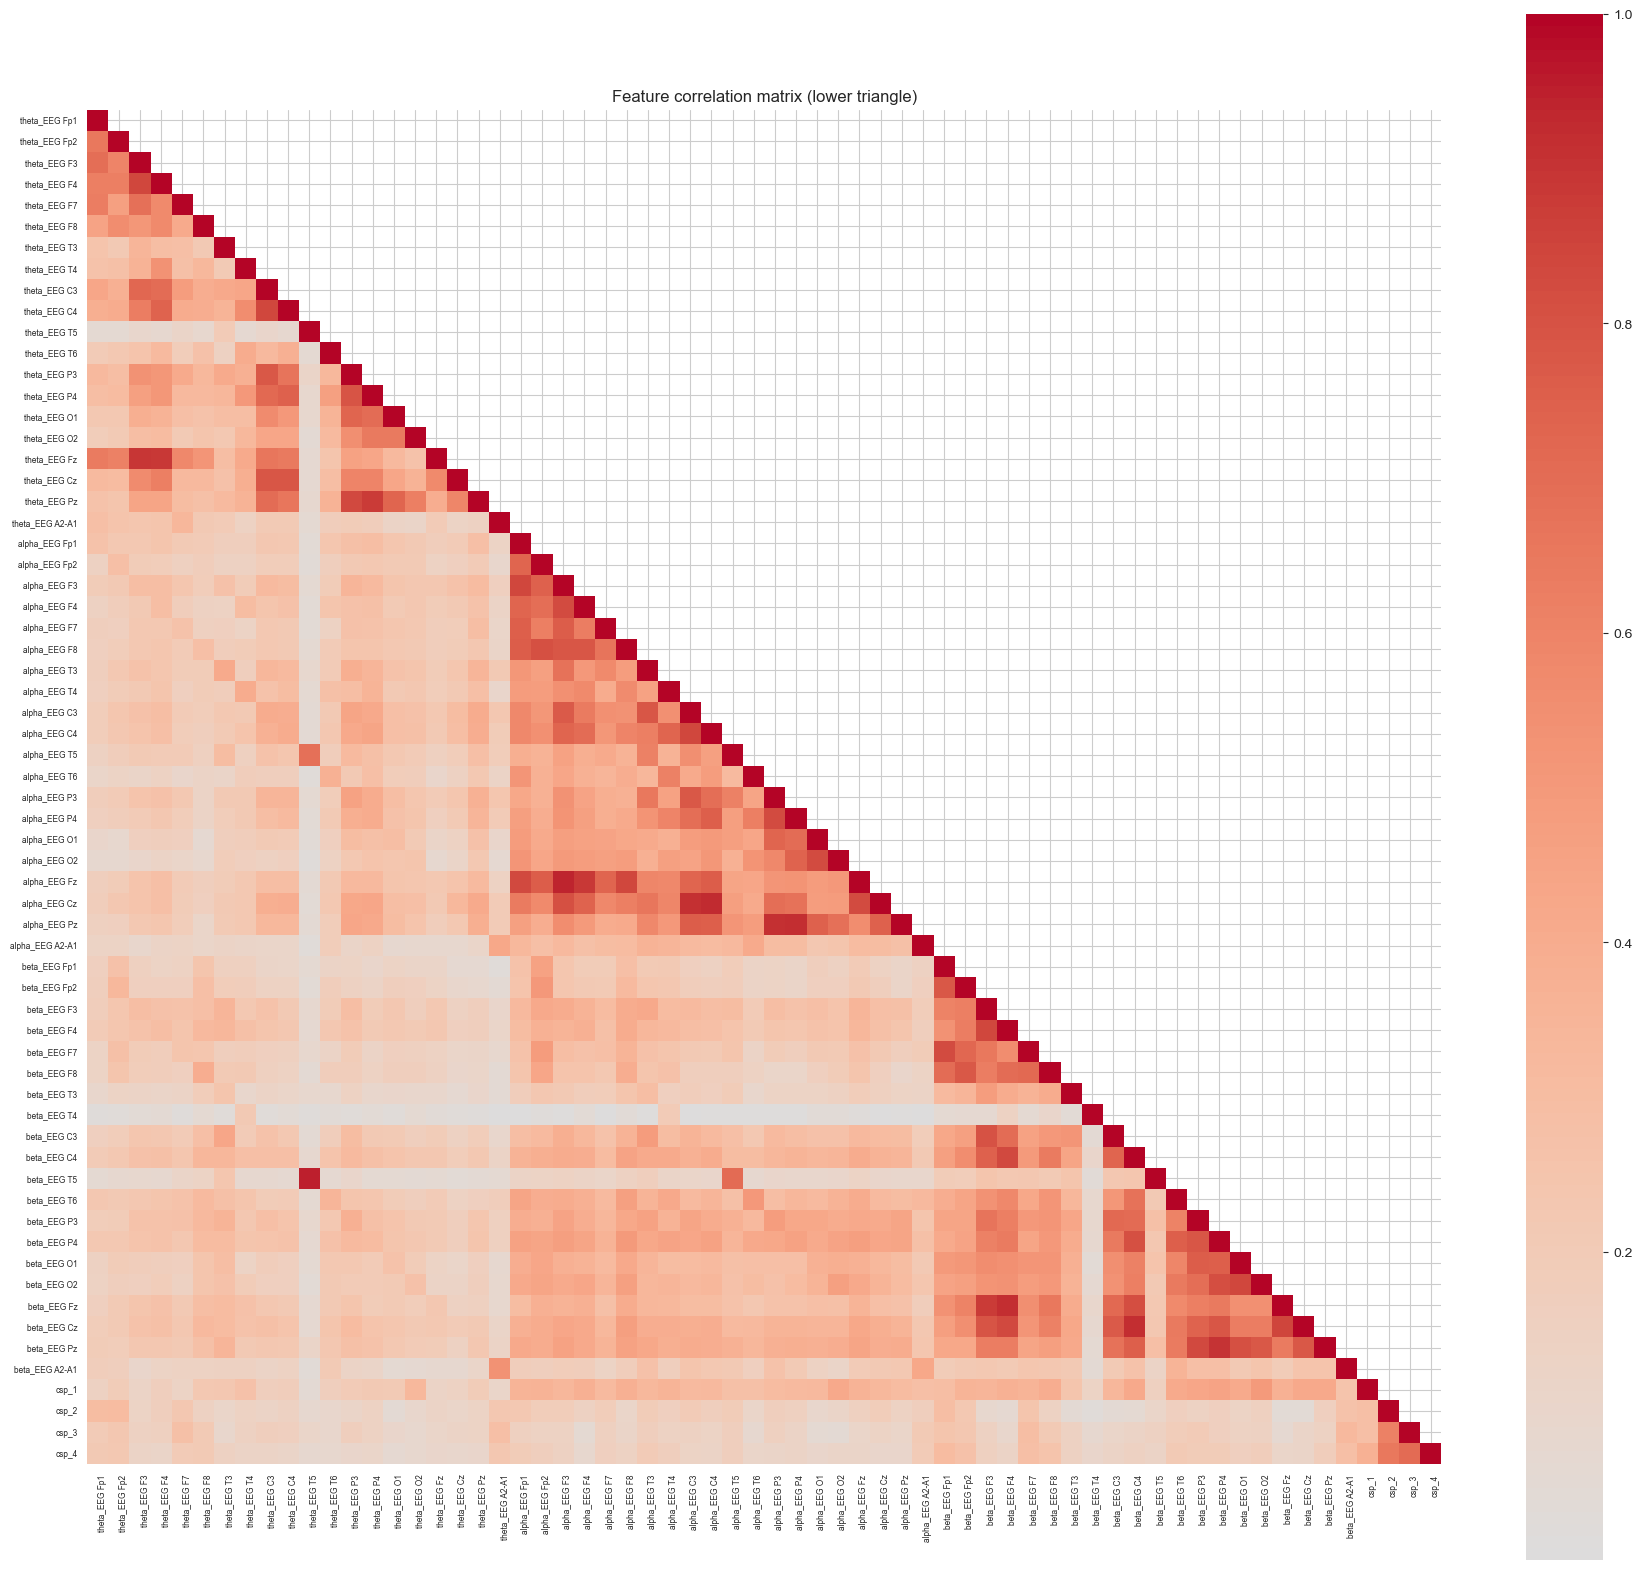

In [55]:
# Correlation matrix of bandpower features
X = df[feature_cols]
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True, ax=ax,
            xticklabels=corr.columns, yticklabels=corr.columns,
            annot=False, fmt=".2f")
ax.tick_params(axis="both", labelsize=6)
plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")
ax.set_title("Feature correlation matrix (lower triangle)")
plt.tight_layout()
plt.show()

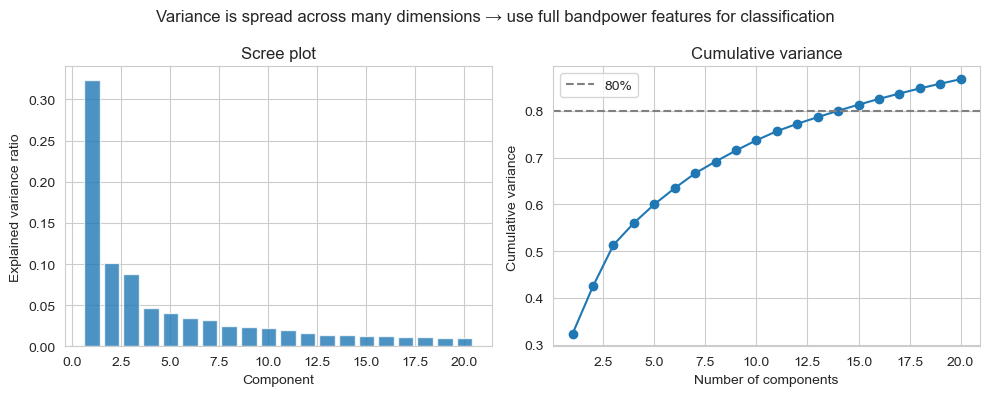

In [53]:
# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(df[feature_cols])
pca = PCA(n_components=min(20, X.shape[1], X.shape[0])).fit(X)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(range(1, len(evr) + 1), evr, alpha=0.8, label="Per component")
ax1.set_xlabel("Component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Scree plot")
ax2.plot(range(1, len(cum) + 1), cum, "o-")
ax2.axhline(0.8, color="gray", linestyle="--", label="80%")
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative variance")
ax2.set_title("Cumulative variance")
ax2.legend()
plt.suptitle("Variance is spread across many dimensions → use full bandpower features for classification")
plt.tight_layout()
plt.show()